In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
np.random.seed(SEED)

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [14]:
df = pd.read_csv('../data/telco_churn.csv')

# Corrigir TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Separar target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Remover customerID (não é feature)
df = df.drop('customerID', axis=1)

# Separar features e target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identificar colunas numéricas e categóricas
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Features numéricas ({len(num_cols)}): {num_cols}")
print(f"Features categóricas ({len(cat_cols)}): {cat_cols}")
print("\nTarget - Churn:")
print(y.value_counts())
print(f"\nShape X: {X.shape}, Shape y: {y.shape}")

Features numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Features categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Target - Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64

Shape X: (7043, 19), Shape y: (7043,)


In [15]:
# Pipeline de pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ]
)

# Split treino/teste estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nProporção churn treino: {y_train.mean():.3f}")
print(f"Proporção churn teste:  {y_test.mean():.3f}")


Treino: 5634 amostras
Teste:  1409 amostras

Proporção churn treino: 0.265
Proporção churn teste:  0.265


In [16]:
# Definir modelos
models = {
    'DummyClassifier': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED)
}

# Treinar e avaliar cada modelo
results = []

for name, model in models.items():
    # Criar pipeline com preprocessamento
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Validação cruzada estratificada
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')

    # Treinar no conjunto completo de treino
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Calcular métricas
    metrics = {
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'CV AUC-ROC (mean)': cv_scores.mean(),
        'CV AUC-ROC (std)': cv_scores.std()
    }
    results.append(metrics)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))

# Tabela comparativa
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("TABELA COMPARATIVA DE MODELOS")
print("="*70)
results_df


  DummyClassifier
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



/Users/rafaelnedermaiorino/projetos/tech-challenge-fase1/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/rafaelnedermaiorino/projetos/tech-challenge-fase1/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/rafaelnedermaiorino/projetos/tech-challenge-fase1/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to con


  Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


  Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409


TABELA COMPARATIVA DE MODELOS


,Modelo,Accuracy,F1-Score,AUC-ROC,Precision,Recall,CV AUC-ROC (mean),CV AUC-ROC (std)
0,DummyClassifier,0.734564,0.000000,0.500000,0.000000,0.000000,0.500000,0.000000
1,Logistic Regression,0.805536,0.604046,0.842006,0.657233,0.558824,0.846101,0.012522
2,Random Forest,0.784954,0.549777,0.825734,0.618729,0.494652,0.823965,0.012038


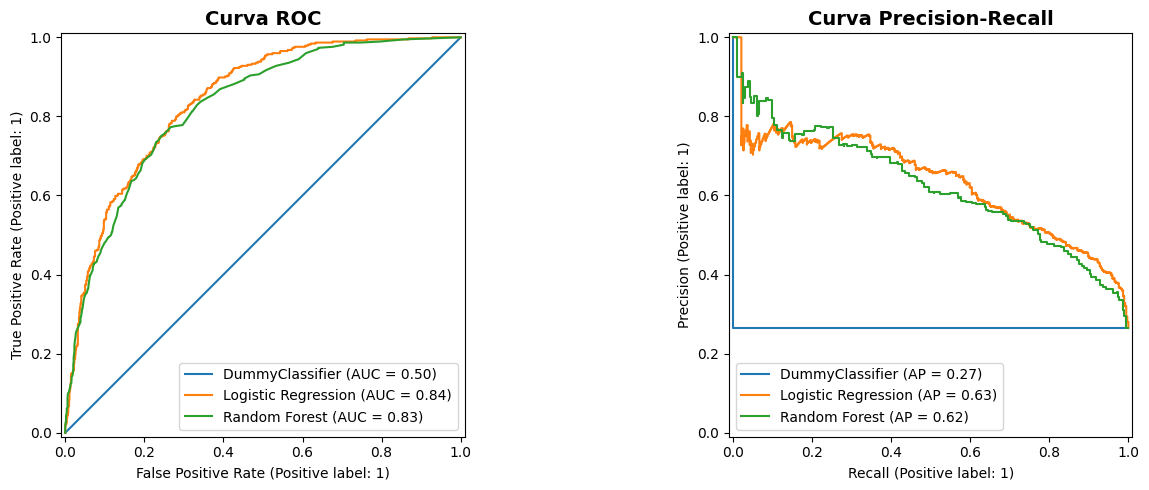

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retreinar pipelines para gerar curvas
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)

axes[0].set_title('Curva ROC', fontsize=14, fontweight='bold')
axes[1].set_title('Curva Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/baseline_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import mlflow
import mlflow.sklearn

# Configurar MLflow
mlflow.set_experiment("churn-baselines")

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1]

        # Logar parâmetros
        mlflow.log_param("model_name", name)
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("seed", SEED)
        mlflow.log_param("dataset_version", "v1.0")

        # Logar métricas
        mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
        mlflow.log_metric("f1_score", f1_score(y_test, y_pred))
        mlflow.log_metric("auc_roc", roc_auc_score(y_test, y_proba))
        mlflow.log_metric("precision", precision_score(y_test, y_pred))
        mlflow.log_metric("recall", recall_score(y_test, y_pred))

        # Salvar modelo
        mlflow.sklearn.log_model(pipe, "model")

        print(f"✅ {name} registrado no MLflow")

print("\n🎉 Todos os experimentos registrados!")
print("Para visualizar: rode 'mlflow ui' no terminal e acesse http://localhost:5000")

/Users/rafaelnedermaiorino/projetos/tech-challenge-fase1/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2026/04/28 18:09:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 18:09:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2026/04/28 18:09:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ DummyClassifier registrado no MLflow


2026/04/28 18:09:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Logistic Regression registrado no MLflow


2026/04/28 18:09:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 18:10:00 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


✅ Random Forest registrado no MLflow

🎉 Todos os experimentos registrados!
Para visualizar: rode 'mlflow ui' no terminal e acesse http://localhost:5000
